In [1]:
#!pip install -q pyarrow pandas matplotlib seaborn plotly scipy 

#!pip install statsmodels "nbformat>=4.2.0" --upgrade

In [2]:
import pyarrow.feather as feather
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from item_classifier import *
from plots import *

In [3]:

table = feather.read_table('../dataset/data_andre.feather', memory_map=True)
df= table.to_pandas()
df.head()

,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
0,2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
1,2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2,2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
3,2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
4,2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [4]:
df_indexed = df.copy()
df_indexed["date"] = pd.to_datetime(df_indexed["date"])
df_indexed = df_indexed.set_index("date").sort_index()
df_indexed.head()

,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [5]:
'''
# Classify all items
df_classified, summary = classify_items(
    df_indexed,
    seasonal_strength_threshold=0.3,    # Adjust based on your domain
    cv_threshold=0.5,                    # Adjust for intermittence detection
    initial_gap_fraction=0.2,            # 20% gap at start = new item
)

# Display summary
print("Label Distribution:")
print(summary['label_counts'])
print("\n" + "="*60)

df_classified.head()
'''


'\n# Classify all items\ndf_classified, summary = classify_items(\n    df_indexed,\n    seasonal_strength_threshold=0.3,    # Adjust based on your domain\n    cv_threshold=0.5,                    # Adjust for intermittence detection\n    initial_gap_fraction=0.2,            # 20% gap at start = new item\n)\n\n# Display summary\nprint("Label Distribution:")\nprint(summary[\'label_counts\'])\nprint("\n" + "="*60)\n\ndf_classified.head()\n'


## Classification Parameters Guide

The classifier uses three main parameters to categorize items:

### 1. `seasonal_strength_threshold` (default: 0.3)
- **What**: Strength of periodicity/seasonality in sales pattern (0-1 scale)
- **Higher values**: More strict seasonality detection
- **Lower values**: Easier to detect seasonal patterns
- **From document**: Items with sales/non-sales cycles that are regular and periodic

### 2. `cv_threshold` (default: 0.5)  
- **What**: Coefficient of Variation in cycle intervals
- **Higher values**: Allow more variability in intervals (more "erratic")
- **Lower values**: Stricter intermittence detection
- **From document**: Intermittent items have intervals that "don't share any common pattern"

### 3. `initial_gap_fraction` (default: 0.2)
- **What**: Fraction of zero-sales at the beginning (0-1 scale)
- **Higher values**: Allow longer initial gaps
- **Lower values**: Stricter new item detection
- **From document**: New items have "meaningful non-sales cycle at the beginning"

## Tuning Tips
- Start with defaults, then adjust based on your visualization results
- If too many items are "seasonal" → increase `seasonal_strength_threshold`
- If too many items are "intermittent" → increase `cv_threshold`
- If too many items are "new" → increase `initial_gap_fraction`


In [6]:
#plot_label_distribution(summary["label_counts"]);

In [14]:
df_classified, labels_df, summary = classify_items_adi_cv(df_indexed)


In [15]:
df_indexed.head()

,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,952568,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,1,0.0,6269
2021-01-23,809,13,juices drnks shelf stbl,pos subd grocery other,pos dept grocery,juice/aseptic/new age,0,0.0,1,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,20405,3,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.1228,0,0.0,0,0.0,0,0.0,0,0.0,6269
2021-01-23,605573,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,0.0,...,0.0000,0,0.0,0,0.0,0,0.0,0,0.0,6269


In [16]:
summary['flag_counts']

{'is_new': 0, 'is_end_of_life': 0}


Detailed Classification Distribution:
Total items: 1427

Breakdown:
  seasonal    :    929 items ( 65.1%)
  lumpy       :    428 items ( 30.0%)
  smooth      :     67 items (  4.7%)
  intermittent:      3 items (  0.2%)


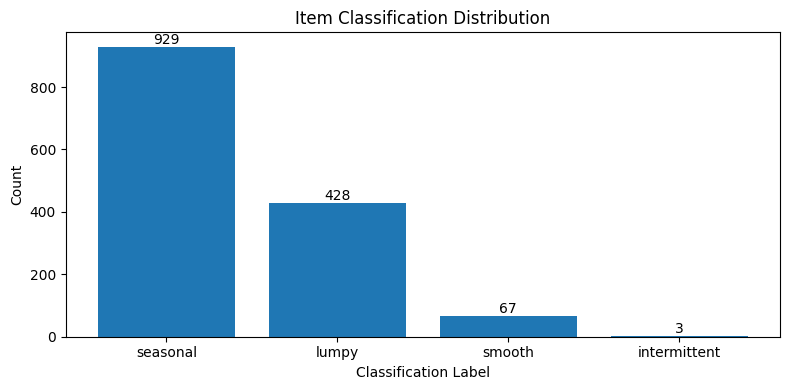

In [17]:
plot_label_distribution(summary['label_counts']);

Product ID: 27
Date range: 2021-01-23 00:00:00 to 2023-02-22 00:00:00
Total records: 761
Non-zero sales: 755

Value statistics:
count    761.000000
mean      11.065703
std        5.683160
min        0.000000
25%        6.000000
50%       10.000000
75%       15.000000
max       31.000000
Name: value, dtype: float64


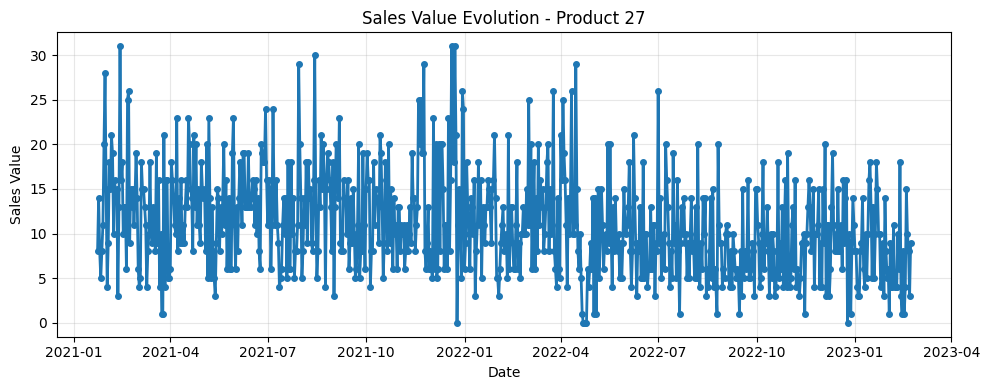

(<Axes: title={'center': 'Sales Value Evolution - Product 27'}, xlabel='Date', ylabel='Sales Value'>,
           date  value
 0   2021-01-23      8
 1   2021-01-24     14
 2   2021-01-25      8
 3   2021-01-26      5
 4   2021-01-27      8
 ..         ...    ...
 756 2023-02-18     15
 757 2023-02-19     10
 758 2023-02-20      8
 759 2023-02-21      3
 760 2023-02-22      9
 
 [761 rows x 2 columns],
 {'product_id': 27,
  'date_min': Timestamp('2021-01-23 00:00:00'),
  'date_max': Timestamp('2023-02-22 00:00:00'),
  'total_records': 761,
  'non_zero_sales': 755,
  'describe': count    761.000000
  mean      11.065703
  std        5.683160
  min        0.000000
  25%        6.000000
  50%       10.000000
  75%       15.000000
  max       31.000000
  Name: value, dtype: float64})

In [18]:
plot_product_value_evolution(df_indexed, selected_product=27, date_col=None, value_col='value')


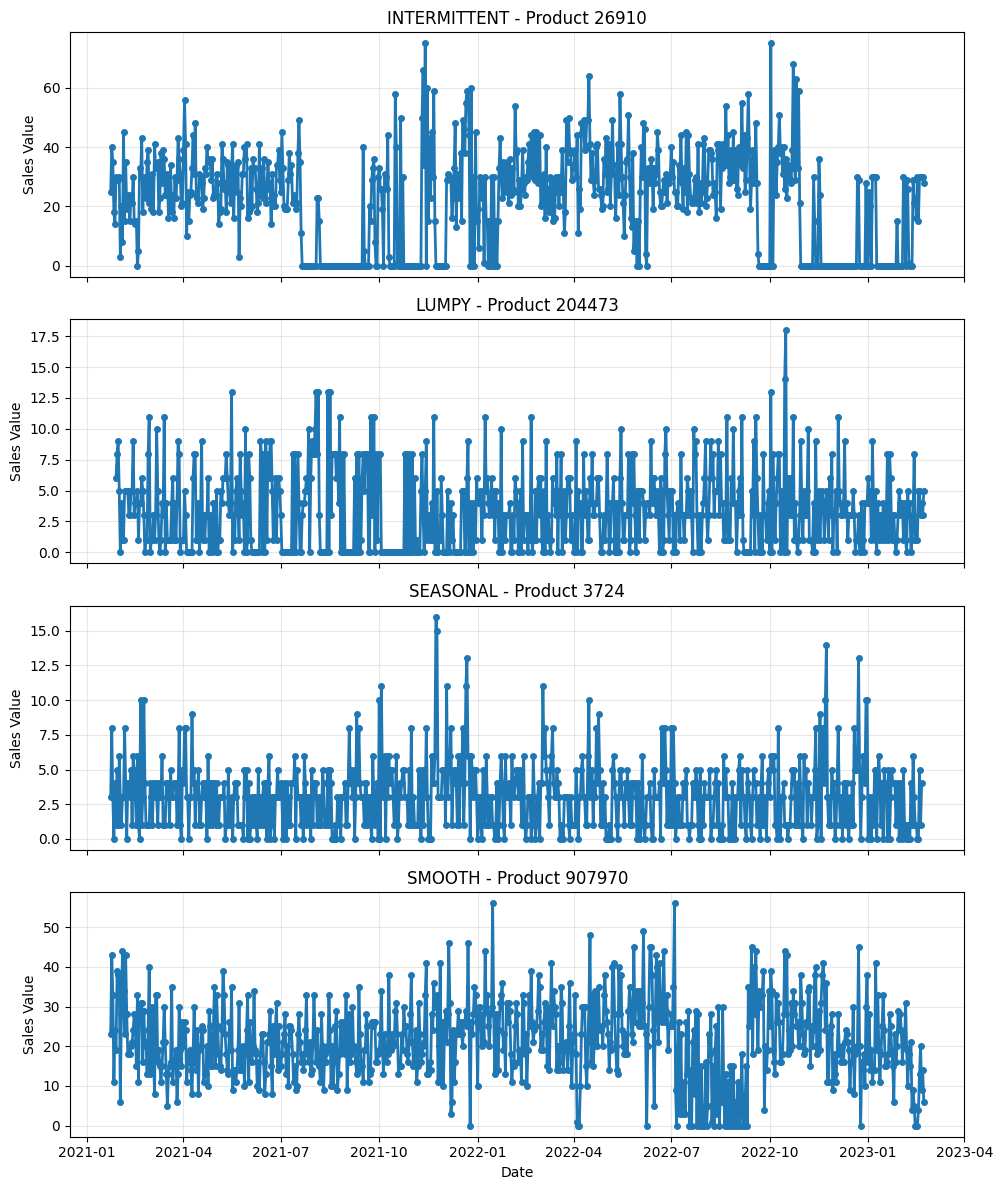

In [46]:
plot_random_sample_per_label(df_indexed, df_classified, date_col=None, seed=None);